In [3]:
import pandas as pd

csv_path = "/kaggle/input/datasets/nikitarom/planets-dataset/planet/planet/train_classes.csv"

df = pd.read_csv(csv_path)

print(df.head())

print("\nColumns:")
print(df.columns)

print("\nShape:")
print(df.shape)

  image_name                                       tags
0    train_0                               haze primary
1    train_1            agriculture clear primary water
2    train_2                              clear primary
3    train_3                              clear primary
4    train_4  agriculture clear habitation primary road

Columns:
Index(['image_name', 'tags'], dtype='object')

Shape:
(40479, 2)


In [4]:
import os
import cv2
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

2026-05-31 18:26:25.059162: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780251985.552453      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780251985.683240      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780251986.739526      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780251986.739575      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780251986.739578      58 computation_placer.cc:177] computation placer alr

In [5]:
DATASET_PATH = "/kaggle/input/datasets/nikitarom/planets-dataset/planet/planet"

CSV_PATH = os.path.join(
    DATASET_PATH,
    "train_classes.csv"
)

IMAGE_DIR = os.path.join(
    DATASET_PATH,
    "train-jpg"
)

OUTPUT_DIR = "/kaggle/working/outputs"

FIGURE_DIR = os.path.join(
    OUTPUT_DIR,
    "figures"
)

TABLE_DIR = os.path.join(
    OUTPUT_DIR,
    "tables"
)

MODEL_DIR = os.path.join(
    OUTPUT_DIR,
    "models"
)

os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print("CSV Exists :", os.path.exists(CSV_PATH))
print("Images Exist :", os.path.exists(IMAGE_DIR))

CSV Exists : True
Images Exist : True


In [6]:
df = pd.read_csv(CSV_PATH)

print("="*70)
print("PLANET AMAZON RAINFOREST DATASET")
print("="*70)

print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

display(df.head())

PLANET AMAZON RAINFOREST DATASET
Shape:
(40479, 2)

Columns:
Index(['image_name', 'tags'], dtype='object')


,image_name,tags
0,train_0,haze primary
1,train_1,agriculture clear primary water
2,train_2,clear primary
3,train_3,clear primary
4,train_4,agriculture clear habitation primary road


In [7]:
df["tags"] = df["tags"].apply(
    lambda x: x.split(" ")
)

mlb = MultiLabelBinarizer()

encoded_labels = mlb.fit_transform(
    df["tags"]
)

label_names = mlb.classes_

label_df = pd.DataFrame(
    encoded_labels,
    columns=label_names
)

dataset_df = pd.concat(
    [
        df["image_name"],
        label_df
    ],
    axis=1
)

print("="*70)
print("MULTI-LABEL INFORMATION")
print("="*70)

print("Total Labels :", len(label_names))

print("\nLabel Names:\n")

for label in label_names:
    print(label)

MULTI-LABEL INFORMATION
Total Labels : 17

Label Names:

agriculture
artisinal_mine
bare_ground
blooming
blow_down
clear
cloudy
conventional_mine
cultivation
habitation
haze
partly_cloudy
primary
road
selective_logging
slash_burn
water


In [8]:
train_df, temp_df = train_test_split(

    dataset_df,

    test_size=0.30,

    random_state=42

)

valid_df, test_df = train_test_split(

    temp_df,

    test_size=0.50,

    random_state=42

)

print("="*70)
print("DATA SPLIT SUMMARY")
print("="*70)

print(f"Training Samples   : {len(train_df)}")
print(f"Validation Samples : {len(valid_df)}")
print(f"Testing Samples    : {len(test_df)}")

split_summary = pd.DataFrame({

    "Dataset Split": [
        "Training",
        "Validation",
        "Testing"
    ],

    "Samples": [
        len(train_df),
        len(valid_df),
        len(test_df)
    ]

})

display(split_summary)

split_summary.to_csv(

    os.path.join(
        TABLE_DIR,
        "dataset_split_summary.csv"
    ),

    index=False
)

DATA SPLIT SUMMARY
Training Samples   : 28335
Validation Samples : 6072
Testing Samples    : 6072


,Dataset Split,Samples
0,Training,28335
1,Validation,6072
2,Testing,6072


In [9]:
IMG_SIZE = 128

def load_image(image_name):

    image_path = os.path.join(
        IMAGE_DIR,
        image_name + ".jpg"
    )

    image = cv2.imread(image_path)

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    image = cv2.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    image = image.astype(np.float32) / 255.0

    return image

In [10]:
class PlanetDataGenerator(
    tf.keras.utils.Sequence
):

    def __init__(
        self,
        dataframe,
        batch_size=32,
        shuffle=True
    ):

        self.dataframe = dataframe.reset_index(drop=True)

        self.batch_size = batch_size

        self.shuffle = shuffle

        self.indexes = np.arange(
            len(self.dataframe)
        )

        self.on_epoch_end()

    def __len__(self):

        return int(
            np.floor(
                len(self.dataframe) /
                self.batch_size
            )
        )

    def __getitem__(
        self,
        index
    ):

        indexes = self.indexes[
            index*self.batch_size:
            (index+1)*self.batch_size
        ]

        batch_df = self.dataframe.iloc[indexes]

        images = []

        labels = []

        for _, row in batch_df.iterrows():

            image = load_image(
                row["image_name"]
            )

            label = row.iloc[1:].values.astype(
                np.float32
            )

            images.append(image)

            labels.append(label)

        return (
            np.array(images),
            np.array(labels)
        )

    def on_epoch_end(self):

        if self.shuffle:

            np.random.shuffle(
                self.indexes
            )

In [11]:
BATCH_SIZE = 32

train_generator = PlanetDataGenerator(
    train_df,
    batch_size=BATCH_SIZE
)

valid_generator = PlanetDataGenerator(
    valid_df,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_generator = PlanetDataGenerator(
    test_df,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Generators Created Successfully")

Generators Created Successfully


In [12]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip(
        "horizontal"
    ),

    tf.keras.layers.RandomRotation(
        0.15
    ),

    tf.keras.layers.RandomZoom(
        0.15
    ),

    tf.keras.layers.RandomContrast(
        0.15
    )

])

I0000 00:00:1780252005.727325      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780252005.733328      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [13]:
inputs = tf.keras.Input(
    shape=(IMG_SIZE, IMG_SIZE, 3)
)

x = data_augmentation(
    inputs
)

x = tf.keras.layers.Conv2D(
    32,
    (3,3),
    activation="relu"
)(x)

x = tf.keras.layers.MaxPooling2D()(x)

x = tf.keras.layers.Conv2D(
    64,
    (3,3),
    activation="relu"
)(x)

x = tf.keras.layers.MaxPooling2D()(x)

x = tf.keras.layers.Conv2D(
    128,
    (3,3),
    activation="relu"
)(x)

x = tf.keras.layers.MaxPooling2D()(x)

x = tf.keras.layers.Conv2D(
    256,
    (3,3),
    activation="relu"
)(x)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(
    0.4
)(x)

x = tf.keras.layers.Dense(
    256,
    activation="relu"
)(x)

outputs = tf.keras.layers.Dense(
    len(label_names),
    activation="sigmoid"
)(x)

cnn_model = tf.keras.Model(
    inputs,
    outputs
)

cnn_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 17)             │         4,369 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 458,577 (1.75 MB)

 Trainable params: 458,577 (1.75 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
cnn_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="binary_crossentropy",

    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="binary_accuracy"
        )
    ]
)

In [15]:
early_stopping = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True
)

history = cnn_model.fit(

    train_generator,

    validation_data=valid_generator,

    epochs=2,

    callbacks=[
        early_stopping
    ]
)

Epoch 1/2


I0000 00:00:1780252013.044453     124 cuda_dnn.cc:529] Loaded cuDNN version 91002


885/885 ━━━━━━━━━━━━━━━━━━━━ 465s 517ms/step - binary_accuracy: 0.9106 - loss: 0.2314 - val_binary_accuracy: 0.9180 - val_loss: 0.2107
Epoch 2/2
885/885 ━━━━━━━━━━━━━━━━━━━━ 149s 168ms/step - binary_accuracy: 0.9204 - loss: 0.2027 - val_binary_accuracy: 0.9217 - val_loss: 0.1935


In [16]:
cnn_model.save(

    os.path.join(
        MODEL_DIR,
        "custom_cnn_model.keras"
    )
)

print("Model Saved Successfully")

Model Saved Successfully


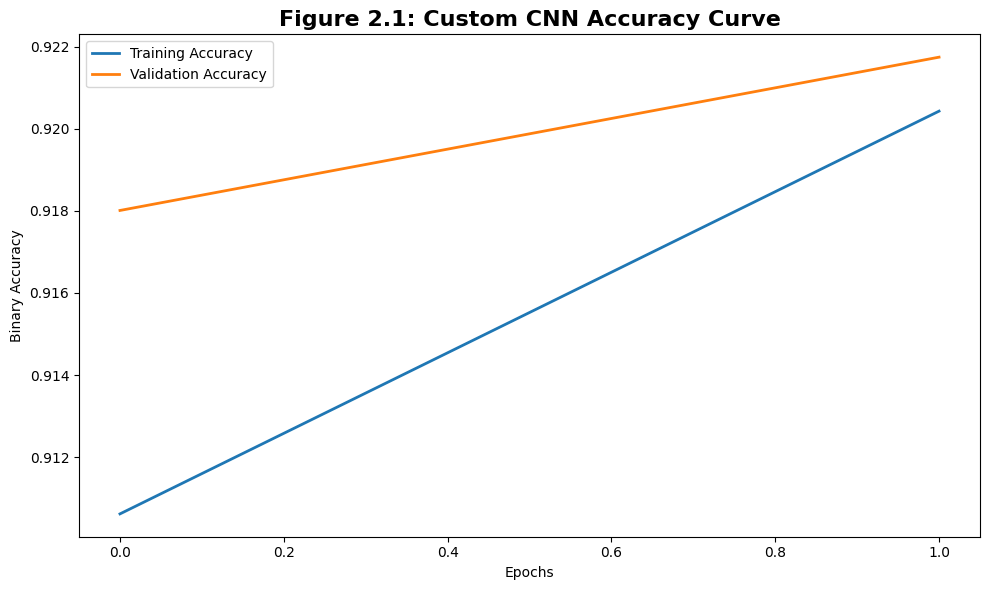

In [17]:
plt.figure(figsize=(10,6))

plt.plot(
    history.history["binary_accuracy"],
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    history.history["val_binary_accuracy"],
    linewidth=2,
    label="Validation Accuracy"
)

plt.title(
    "Figure 2.1: Custom CNN Accuracy Curve",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Epochs")

plt.ylabel("Binary Accuracy")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "custom_cnn_accuracy_curve.pdf"
    )
)

plt.show()

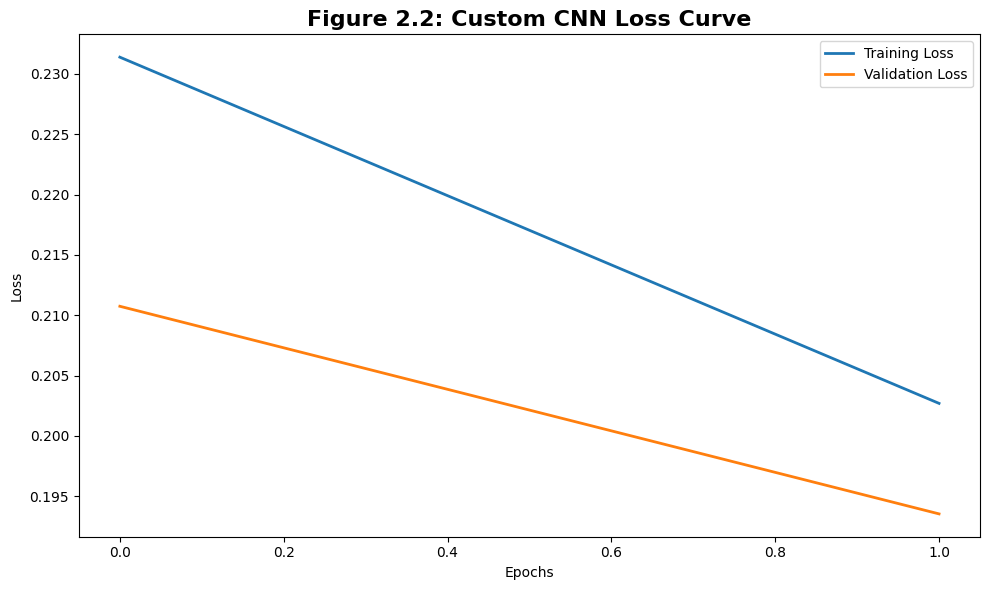

In [18]:
plt.figure(figsize=(10,6))

plt.plot(
    history.history["loss"],
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    linewidth=2,
    label="Validation Loss"
)

plt.title(
    "Figure 2.2: Custom CNN Loss Curve",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "custom_cnn_loss_curve.pdf"
    )
)

plt.show()

In [19]:
results = cnn_model.evaluate(
    test_generator
)

print("="*70)
print("CUSTOM CNN TEST RESULTS")
print("="*70)

for metric, value in zip(
    cnn_model.metrics_names,
    results
):
    print(
        f"{metric}: {value:.4f}"
    )

189/189 ━━━━━━━━━━━━━━━━━━━━ 72s 381ms/step - binary_accuracy: 0.9226 - loss: 0.1916
CUSTOM CNN TEST RESULTS
loss: 0.1916
compile_metrics: 0.9226


In [20]:
predictions = cnn_model.predict(
    test_generator
)

y_pred = (
    predictions > 0.5
).astype(int)

189/189 ━━━━━━━━━━━━━━━━━━━━ 22s 116ms/step


In [21]:
y_true = []

for _, labels in test_generator:

    y_true.extend(labels)

y_true = np.array(y_true)

print(y_true.shape)

(6048, 17)


In [22]:
from sklearn.metrics import classification_report

report = classification_report(

    y_true,

    y_pred,

    target_names=label_names,

    output_dict=True
)

report_df = pd.DataFrame(
    report
).transpose()

report_df.to_csv(

    os.path.join(
        TABLE_DIR,
        "custom_cnn_classification_report.csv"
    )
)

report_df.head()

,precision,recall,f1-score,support
agriculture,0.672924,0.509847,0.580143,1828.0
artisinal_mine,0.233333,0.152174,0.184211,46.0
bare_ground,0.000000,0.000000,0.000000,145.0
blooming,0.000000,0.000000,0.000000,52.0
blow_down,0.000000,0.000000,0.000000,10.0


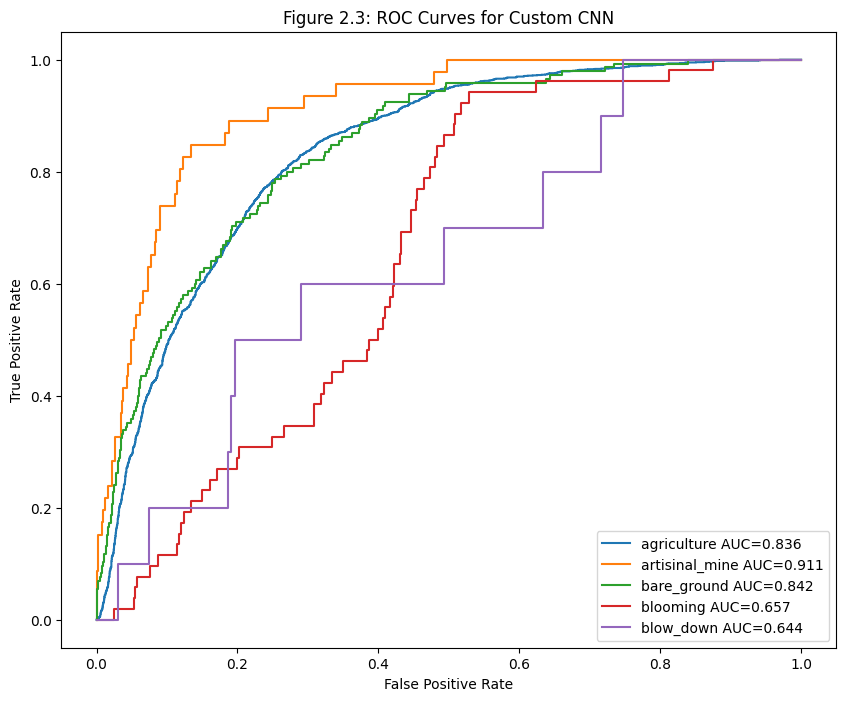

In [23]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

plt.figure(figsize=(10,8))

for i in range(5):

    fpr, tpr, _ = roc_curve(
        y_true[:,i],
        predictions[:,i]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{label_names[i]} AUC={roc_auc:.3f}"
    )

plt.title(
    "Figure 2.3: ROC Curves for Custom CNN"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.legend()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "custom_cnn_roc_curve.pdf"
    )
)

plt.show()

In [24]:
from sklearn.metrics import multilabel_confusion_matrix

confusion_matrices = multilabel_confusion_matrix(

    y_true,

    y_pred
)

print(
    confusion_matrices.shape
)

(17, 2, 2)


In [25]:
metrics_df = pd.DataFrame({

    "Metric": cnn_model.metrics_names,

    "Value": results

})

metrics_df.to_csv(

    os.path.join(
        TABLE_DIR,
        "custom_cnn_metrics.csv"
    ),

    index=False
)

metrics_df

,Metric,Value
0,loss,0.19155
1,compile_metrics,0.92261


In [26]:
print("="*70)
print("NOTEBOOK 2 COMPLETED SUCCESSFULLY")
print("="*70)

print("""
Generated Outputs

Custom CNN Model
Accuracy Curves
Loss Curves
ROC Curves
Classification Report
Confusion Matrices
Evaluation Metrics
Saved Model

All outputs saved successfully.
""")

NOTEBOOK 2 COMPLETED SUCCESSFULLY

Generated Outputs

Custom CNN Model
Accuracy Curves
Loss Curves
ROC Curves
Classification Report
Confusion Matrices
Evaluation Metrics
Saved Model

All outputs saved successfully.



In [27]:
print(os.listdir(MODEL_DIR))

['custom_cnn_model.keras']


In [28]:
print(os.listdir(FIGURE_DIR))

['custom_cnn_accuracy_curve.pdf', 'custom_cnn_loss_curve.pdf', 'custom_cnn_roc_curve.pdf']


In [29]:
import os

print(os.listdir(TABLE_DIR))

['dataset_split_summary.csv', 'custom_cnn_metrics.csv', 'custom_cnn_classification_report.csv']


In [30]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [31]:
history.history.keys()

dict_keys(['binary_accuracy', 'loss', 'val_binary_accuracy', 'val_loss'])

In [32]:
cnn_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 17)             │         4,369 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,375,733 (5.25 MB)

 Trainable params: 458,577 (1.75 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 917,156 (3.50 MB)

In [33]:
print("Image Size Used:", IMG_SIZE)

Image Size Used: 128


In [34]:
metrics_df

,Metric,Value
0,loss,0.19155
1,compile_metrics,0.92261


In [35]:
print(results)

[0.1915501058101654, 0.9226095080375671]


In [36]:
print("GPU:", tf.config.list_physical_devices('GPU'))
print("IMG_SIZE:", IMG_SIZE)
print("Epochs:", len(history.history['loss']))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
IMG_SIZE: 128
Epochs: 2


In [37]:
import pandas as pd
import os

print(os.listdir("/kaggle/working/outputs/tables"))

['dataset_split_summary.csv', 'custom_cnn_metrics.csv', 'custom_cnn_classification_report.csv']


In [38]:
import os
import shutil

FINAL_OUTPUT_DIR = "/kaggle/working/FINAL_PROJECT_OUTPUTS"

os.makedirs(
    FINAL_OUTPUT_DIR,
    exist_ok=True
)

for root, dirs, files in os.walk("/kaggle/working"):

    for file in files:

        if file.endswith(
            (
                ".pdf",
                ".csv",
                ".keras"
            )
        ):

            source = os.path.join(
                root,
                file
            )

            destination = os.path.join(
                FINAL_OUTPUT_DIR,
                file
            )

            try:

                shutil.copy2(
                    source,
                    destination
                )

            except:
                pass

print("ALL OUTPUT FILES COPIED SUCCESSFULLY")

ALL OUTPUT FILES COPIED SUCCESSFULLY


In [39]:
import os

print("="*80)
print("FINAL PROJECT OUTPUTS")
print("="*80)

print(
    os.listdir(
        "/kaggle/working/FINAL_PROJECT_OUTPUTS"
    )
)

print("="*80)
print("READY FOR KAGGLE SAVE VERSION")
print("="*80)

FINAL PROJECT OUTPUTS
['custom_cnn_accuracy_curve.pdf', 'dataset_split_summary.csv', 'custom_cnn_loss_curve.pdf', 'custom_cnn_model.keras', 'custom_cnn_metrics.csv', 'custom_cnn_roc_curve.pdf', 'custom_cnn_classification_report.csv']
READY FOR KAGGLE SAVE VERSION
